In [2]:
# Cleaning Data
import pandas as pd
df = pd.read_csv("raw_data.csv")

df.isnull()    # or isna()  same func

df.isnull().sum()   # number of missing values in each column

df.dropna()       # removes rows with nan values

df.dropna(axis = 1)     # removes columns with nan values

df.fillna(0)       # nan values replaced by 0

df["age"].fillna(df["age"].mean())  # nan values replaced by age mean inside age column

cleaned_data = df.copy()
cleaned_data["age"] = df["age"].fillna(df["age"].mean()) 

cleaned_data

df.ffill()
df.bfill()



,id,name,age,country,gender
0,1,Amit,21.0,India,M
1,2,John,22.0,India,F
2,3,John,20.0,USA,M
3,4,Sara,20.0,UK,F
4,5,Ali,23.0,Canada,F
5,6,Ali,19.0,India,M
6,7,Riya,19.0,India,F
7,8,Meena,24.0,USA,F
8,9,David,22.0,UK,M
9,10,Neha,22.0,India,F


In [3]:
df

,id,name,age,country,gender
0,1,Amit,21.0,India,M
1,2,NaN,22.0,India,F
2,3,John,NaN,USA,M
3,4,Sara,20.0,UK,F
4,5,NaN,23.0,Canada,F
5,6,Ali,NaN,India,M
6,7,Riya,19.0,India,F
7,8,Meena,24.0,USA,F
8,9,David,NaN,UK,M
9,10,Neha,22.0,India,F


In [4]:
# handle Duplicates

df["country"].duplicated()

df2 = df.copy()

df2.drop_duplicates(inplace=True)    # inplace means in real data

In [5]:
df

,id,name,age,country,gender
0,1,Amit,21.0,India,M
1,2,NaN,22.0,India,F
2,3,John,NaN,USA,M
3,4,Sara,20.0,UK,F
4,5,NaN,23.0,Canada,F
5,6,Ali,NaN,India,M
6,7,Riya,19.0,India,F
7,8,Meena,24.0,USA,F
8,9,David,NaN,UK,M
9,10,Neha,22.0,India,F


In [6]:
# Data types
df.dtypes
df2 = df.copy()

df2 = df2.fillna(0)
df2 = df["age"].astype("float64").copy()
df2.dtypes

dtype('float64')

In [7]:
aqi_data = pd.read_csv("globalAirQuality.csv")
aqi_data["timestamp"] = pd.to_datetime(aqi_data["timestamp"])

aqi_data["timestamp"].dtype

dtype('<M8[ns]')

In [8]:
date_str = pd.Series([pd.to_datetime("2026-12-31")])
type(date_str.dtypes)

numpy.dtypes.DateTime64DType

In [9]:
df["gender"].str.upper()
df["gender"].str.capitalize()
df["gender"].str.split("@")
df["gender"].str.contains("US", case=False)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
Name: gender, dtype: bool

In [10]:
# Feature  Engineering ( new feature tax added)
df = pd.read_csv("Employee.csv")
df2 = df.copy()

df2["tax"] = df2["income"].apply(lambda x : "20%" if x >= 50000 else "10%")

gender_map = {"Male" : "M", "Female" : "F"}     # gender values changed

df2["gender"] = df2["gender"].map(gender_map)


df2["country"] = df2["country"].replace("India", "US")   # replaves vountry values india by us

df2.assign(new_income = df2["income"] * 1.1)     # new income col formed

df2["income"].sort_values()
df2.sort_values(["income", "age"])        # if same income then age used for sorting

sorted_df = df2.sort_values("income", ascending=False)

sorted_df.sort_index   # back to original form

# reset
sorted_df.reset_index()

sorted_df.reset_index(drop=True)

#ranking
sorted_df["Ranking"] = sorted_df["income"].rank(ascending=False, method="min")
sorted_df["Ranking"] = sorted_df["income"].rank()


sorted_df[["id", "name", "age", "tax", "country", "income", "gender"]]   # reorder





 




,id,name,age,tax,country,income,gender
8,9,Vivaan,28,20%,US,52000,M
14,15,Karan,27,20%,US,51000,M
4,5,Arjun,26,20%,US,50000,M
6,7,Kabir,27,10%,US,48000,M
12,13,Aditya,26,10%,US,47000,M
3,4,Meera,25,10%,US,45000,F
13,14,Priya,25,10%,US,44000,F
10,11,Reyansh,23,10%,US,41000,M
2,3,Rohan,23,10%,US,40000,M
9,10,Ishita,24,10%,US,36000,F


In [11]:
# To change order of columns (id should be at last)
df2 = df.copy()

new_col_order = [col for col in df2.columns if col != "id"] + ["id"]
print(new_col_order)

df2[new_col_order]

['name', 'age', 'country', 'gender', 'income', 'id']


,name,age,country,gender,income,id
0,Ayaan,22,India,Male,30000,1
1,Zoya,24,India,Female,35000,2
2,Rohan,23,India,Male,40000,3
3,Meera,25,India,Female,45000,4
4,Arjun,26,India,Male,50000,5
5,Sara,22,India,Female,32000,6
6,Kabir,27,India,Male,48000,7
7,Anaya,21,India,Female,29000,8
8,Vivaan,28,India,Male,52000,9
9,Ishita,24,India,Female,36000,10


In [30]:
# how to write in a csv file

df2 = df.copy()

df2 = df2.drop_duplicates()
df2 = df2.fillna(0)
df2 = df2.sort_values("income") 

df2 = df2.reset_index(drop=True)

df2.to_csv("sorted_data.csv") 

In [32]:
#Grouping and aggregation of data

df.groupby("country")["income"].mean()
df.groupby("country")["income"].min()
df.groupby("country")["income"].max()

df.groupby("gender")["income"].max()

df.groupby("age")["income"].agg(avg_salary="mean", min_salary="min", max_salary="max")

df.groupby("gender").agg({
    "income" : "max",
    "age" : "min"
})

df.groupby("gender").agg(
    max_salary=("income", "max"),
    min_age=("age", "min")
)


,max_salary,min_age
gender,,
Female,45000,21
Male,52000,22


In [43]:

df = pd.DataFrame({
    "country":["USA", "USA", "India", "India"],
    "year": [2020, 2021, 2020, 2021],
    "sales": [100, 120, 90, 110],
    "profit": [20, 25, 18, 22],
    "tax": [10, 20, 30, 40]
})

  # Melting dataframe

melted_df = df.melt(
    id_vars=["country", "year"],
    value_vars=["sales", "profit", "tax"],
    var_name="metrics",
    value_name="value"
)


# Pivot( to restore to original form )
original = melted_df.pivot(
    index=["country", "year"],
    columns="metrics",
    values="value"
)

In [40]:
df

,country,year,sales,profit,tax
0,USA,2020,100,20,10
1,USA,2021,120,25,20
2,India,2020,90,18,30
3,India,2021,110,22,40


In [44]:
melted_df

,country,year,metrics,value
0,USA,2020,sales,100
1,USA,2021,sales,120
2,India,2020,sales,90
3,India,2021,sales,110
4,USA,2020,profit,20
5,USA,2021,profit,25
6,India,2020,profit,18
7,India,2021,profit,22
8,USA,2020,tax,10
9,USA,2021,tax,20


In [45]:
original

metrics       profit  sales  tax
country year                    
India   2020      18     90   30
        2021      22    110   40
USA     2020      20    100   10
        2021      25    120   20

<Axes: xlabel='age', ylabel='income'>

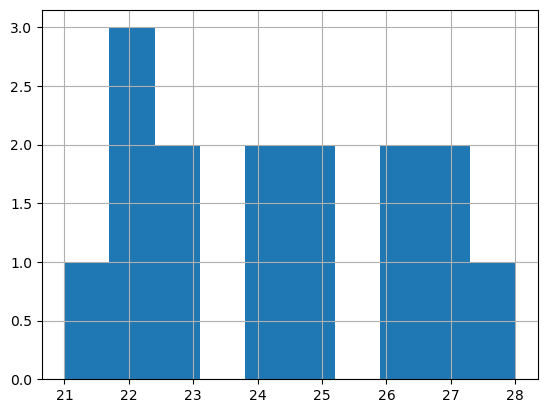

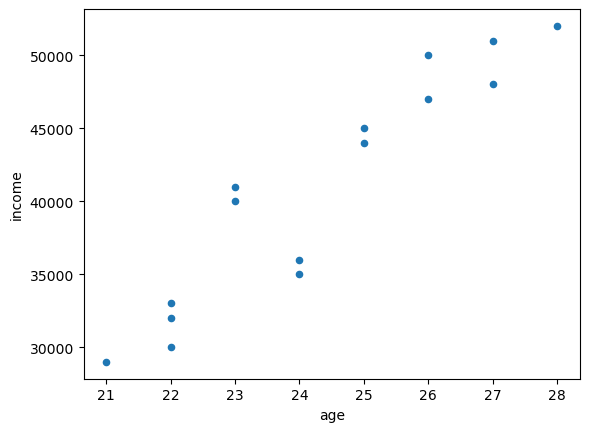

In [48]:
# Basic Visualization

df = pd.read_csv("Employee.csv")

df["age"].hist()   # Histogram
df.plot(kind="scatter", x="age", y="income")


In [60]:
#Merging and joining Data

df_customers = pd.DataFrame({
    "customer_id": [1, 2, 3, 4],
    "name": ["Adam", "Bob", "Charlie", "Dave"]
})

df_orders = pd.DataFrame({
    "order_id": [101, 102, 103, 104],
    "customer_id": [2, 1, 4, 5],
    "amount": [250, 120, 300, 180]
})

pd.merge(df_customers, df_orders, on="customer_id")   # Inner Join
pd.merge(df_customers, df_orders, on="customer_id", how="left")   # Left Join
pd.merge(df_customers, df_orders, on="customer_id", how="right")   # Right Join
pd.merge(df_customers, df_orders, on="customer_id", how="outer")   # outer Join

        

,customer_id,name,order_id,amount
0,1,Adam,102.0,120.0
1,2,Bob,101.0,250.0
2,3,Charlie,NaN,NaN
3,4,Dave,103.0,300.0
4,5,NaN,104.0,180.0


In [55]:
df_customers

,customer_id,name
0,1,Adam
1,2,Bob
2,3,Charlie
3,4,Dave


In [56]:
df_orders

,order_id,customer_id,amount
0,101,2,250
1,102,1,120
2,103,4,300
3,104,5,180


In [65]:
# Data Concatenation

df1 = pd.DataFrame({
    "id" : [1, 2, 3],
    "name" : ["Adam", "Eve", "Bob"]
})

df2 = pd.DataFrame({
    "id" : [4, 5, 6],
    "name" : ["charlie", "Fester", "Gilian"]
})

pd.concat([df1, df2])     # Rows stacked
pd.concat([df1, df2], ignore_index=True)     # Rows stacked with new 

pd.concat([df1, df2], axis=1)   # Columns stacked





,id,name,id,name
0,1,Adam,4,charlie
1,2,Eve,5,Fester
2,3,Bob,6,Gilian


In [62]:
df1

,id,name
0,1,Adam
1,2,Eve
2,3,Bob


In [63]:
df2

,id,name
0,4,charlie
1,5,Fester
2,6,Gilian
